In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [45]:
df = pd.read_csv("./titanic_toy.csv")
df.sample(5)

,Age,Fare,Family,Survived
270,NaN,31.0000,0,0
158,NaN,8.6625,0,0
462,47.0,38.5000,0,0
214,NaN,7.7500,1,0
587,60.0,79.2000,2,1


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [47]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [48]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

In [49]:
X_train,X_test,y_train,_y_test = train_test_split(X,y,test_size=0.2,random_state=2)
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [50]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [51]:
mean_age = X_train["Age"].mean()
median_age = X_train["Age"].median()

mean_fare = X_train["Fare"].mean()
median_fare = X_train["Fare"].median()

In [52]:
X_train["Age_Mean"] = X_train["Age"].fillna(mean_age)
X_train["Age_Median"] = X_train["Age"].fillna(median_age)

X_train["Fare_Mean"] = X_train["Fare"].fillna(mean_fare)
X_train["Fare_Median"] = X_train["Fare"].fillna(median_age)

In [53]:
X_train.sample(5)

,Age,Fare,Family,Age_Mean,Age_Median,Fare_Mean,Fare_Median
167,45.00,27.9000,5,45.000000,45.00,27.900000,27.9000
72,21.00,73.5000,0,21.000000,21.00,73.500000,73.5000
469,0.75,NaN,3,0.750000,0.75,32.617597,28.7500
497,NaN,15.1000,0,29.785904,28.75,15.100000,15.1000
704,26.00,7.8542,1,26.000000,26.00,7.854200,7.8542


In [54]:
print('Original Age variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_Median'].var())
print('Age Variance after mean imputation: ', X_train['Age_Mean'].var())

print('Original Fare variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_Median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_Mean'].var())

Original Age variance:  204.34951339046142
Age Variance after median imputation:  161.98956633460548
Age Variance after mean imputation:  161.81262452718676
Original Fare variance:  2448.1979137063163
Fare Variance after median imputation:  2324.957613614932
Fare Variance after mean imputation:  2324.2385256705534


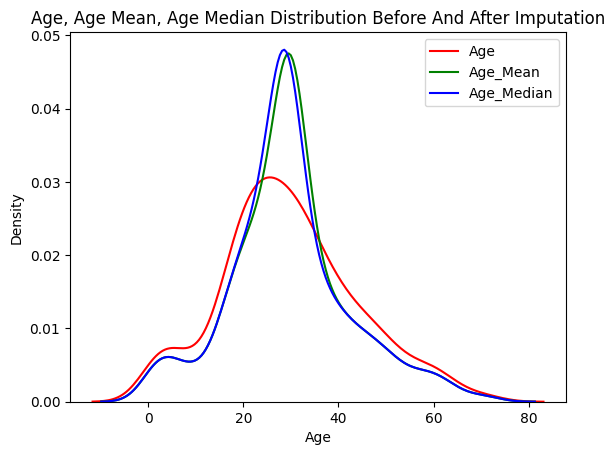

In [55]:
sns.kdeplot(X_train["Age"], color="red", label="Age")
sns.kdeplot(X_train["Age_Mean"], color="green", label="Age_Mean")
sns.kdeplot(X_train["Age_Median"], color="blue", label="Age_Median")

plt.title("Age, Age Mean, Age Median Distribution Before And After Imputation")
plt.legend()
plt.show()

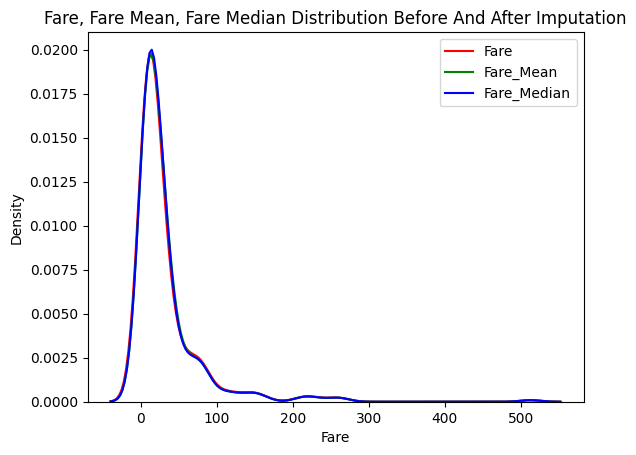

In [56]:
sns.kdeplot(X_train["Fare"], color="red", label="Fare")
sns.kdeplot(X_train["Fare_Mean"], color="green", label="Fare_Mean")
sns.kdeplot(X_train["Fare_Median"], color="blue", label="Fare_Median")

plt.title("Fare, Fare Mean, Fare Median Distribution Before And After Imputation")
plt.legend()
plt.show()

In [57]:
X_train.cov()

,Age,Fare,Family,Age_Mean,Age_Median,Fare_Mean,Fare_Median
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.665205,66.280487
Fare,70.719262,2448.197914,17.258917,55.603719,57.957599,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.146106,-5.112563,16.385048,16.404484
Age_Mean,204.349513,55.603719,-5.146106,161.812625,161.812625,52.788341,52.483705
Age_Median,204.349513,57.957599,-5.112563,161.812625,161.989566,55.023037,54.710043
Fare_Mean,66.665205,2448.197914,16.385048,52.788341,55.023037,2324.238526,2324.238526
Fare_Median,66.280487,2448.197914,16.404484,52.483705,54.710043,2324.238526,2324.957614


In [58]:
X_train.corr()

,Age,Fare,Family,Age_Mean,Age_Median,Fare_Mean,Fare_Median
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.090156,0.089604
Fare,0.092644,1.000000,0.208268,0.088069,0.091757,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.244610,-0.242883,0.205499,0.205710
Age_Mean,1.000000,0.088069,-0.244610,1.000000,0.999454,0.086078,0.085568
Age_Median,1.000000,0.091757,-0.242883,0.999454,1.000000,0.089673,0.089149
Fare_Mean,0.090156,1.000000,0.205499,0.086078,0.089673,1.000000,0.999845
Fare_Median,0.089604,1.000000,0.205710,0.085568,0.089149,0.999845,1.000000


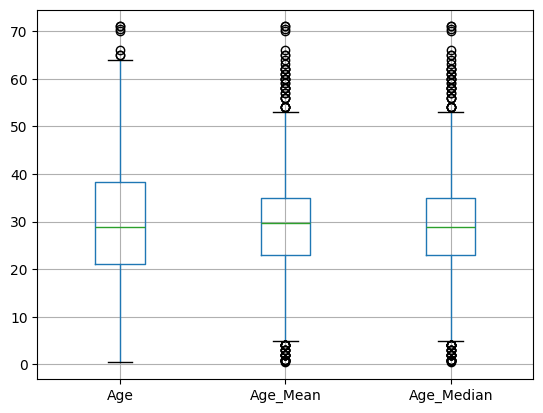

In [59]:
X_train[["Age", "Age_Mean", "Age_Median"]].boxplot()
plt.show()

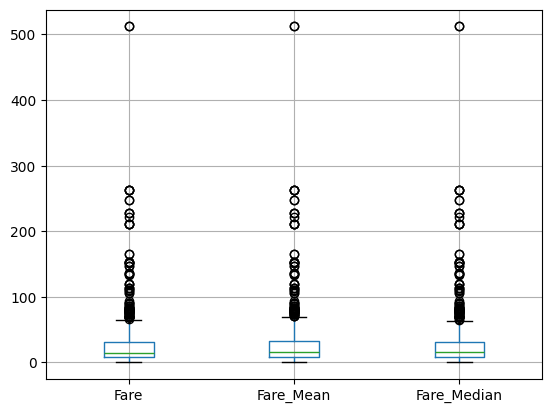

In [60]:
X_train[["Fare", "Fare_Mean", "Fare_Median"]].boxplot()
plt.show()

Using Sklearn

In [61]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [62]:
imputer1 = SimpleImputer(strategy="median")
imputer2 = SimpleImputer(strategy="mean")

In [63]:
trf = ColumnTransformer([
    ("imputer1",imputer1,["Age"]),
    ("imputer2",imputer2,["Fare"])
],remainder="passthrough")

In [64]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [65]:
trf.named_transformers_["imputer1"].statistics_

array([28.75])

In [66]:
trf.named_transformers_["imputer2"].statistics_

array([32.61759689])

In [67]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [68]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))